In [1]:
import os
from collections import defaultdict
from itertools import chain

import polars as pl

from social_groups.analysis.polars_transformations import make_group_constellation
from social_groups.reporting.analysis_columns import AnalysisColumn
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
    SingularityVote,
)
from social_groups.reporting.parsing import (
    AnswerOptions,
    AnswerParser,
    AnswerComparer,
)
from social_groups.directories import REPORTING_DIR
from social_groups.polars_values import MODEL_NAME_TO_LETTER_MAPPING
from social_groups.reporting.group_decision_scheme import calculate_decision_scheme

from social_groups.analysis.polars_transformations.apply_parsing_and_group_decision import (
    apply_parsing_and_group_decision,
)
import social_groups.polars_values as plv
import social_groups.polars_columns as plc

%load_ext autoreload
%autoreload 2

In [2]:

triple_underscore_handling = "wrong"

parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling=triple_underscore_handling
)

In [3]:

from social_groups.analysis.definitions import defs

diversity_frame: pl.DataFrame = defs.load_fn().load_asset_value("diversity_params_mad")

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:111: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-02-21 19:27:13 +0800 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/diversity_params_mad.parquet using PolarsParquetIOManager...


In [4]:
diversity_frame.head()

shape: (5, 19)
┌─────┬────────┬─────────────┬──────────────┬───┬──────────────┬─────────────┬───────┬─────────────┐
│ id  ┆ run_id ┆ question_id ┆ phoenix_span ┆ … ┆ answer_strin ┆ temperature ┆ top_p ┆ group_const │
│ --- ┆ ---    ┆ ---         ┆ _id          ┆   ┆ g            ┆ ---         ┆ ---   ┆ ellation    │
│ i64 ┆ i64    ┆ i64         ┆ ---          ┆   ┆ ---          ┆ f64         ┆ f64   ┆ ---         │
│     ┆        ┆             ┆ str          ┆   ┆ str          ┆             ┆       ┆ str         │
╞═════╪════════╪═════════════╪══════════════╪═══╪══════════════╪═════════════╪═══════╪═════════════╡
│ 580 ┆ 6      ┆ 15          ┆ bfa6bd5b4892 ┆ … ┆ B            ┆ 0.7         ┆ 1.0   ┆ HM          │
│     ┆        ┆             ┆ de49         ┆   ┆              ┆             ┆       ┆             │
│ 581 ┆ 6      ┆ 5           ┆ 0fc972b5bec1 ┆ … ┆ A            ┆ 0.7         ┆ 1.0   ┆ HM          │
│     ┆        ┆             ┆ 3330         ┆   ┆              ┆             ┆       ┆             │
│ 582 ┆ 6      ┆ 6           ┆ 6eb07b84cad6 ┆ … ┆ C            ┆ 0.7         ┆ 1.0   ┆ HM          │
│     ┆        ┆             ┆ d05f         ┆   ┆              ┆             ┆       ┆             │
│ 583 ┆ 6      ┆ 13          ┆ 87c444a3c37f ┆ … ┆ C            ┆ 0.7         ┆ 1.0   ┆ HM          │
│     ┆        ┆             ┆ 3b7f         ┆   ┆              ┆             ┆       ┆             │
│ 584 ┆ 6      ┆ 8           ┆ 21ddda092596 ┆ … ┆ E            ┆ 0.7         ┆ 1.0   ┆ HM          │
│     ┆        ┆             ┆ 6631         ┆   ┆              ┆             ┆       ┆             │
└─────┴────────┴─────────────┴──────────────┴───┴──────────────┴─────────────┴───────┴─────────────┘

In [5]:
diversity_frame = apply_parsing_and_group_decision(
    diversity_frame, parser, comparer, group_reply
)

In [14]:
diversity_data = diversity_frame.group_by(plc.group_constellation, "top_p", "temperature").agg(
    pl.mean(plc.is_correct).alias(plc.accuracy)).sort(plc.accuracy, descending=True)

In [15]:
diversity_data

group_constellation,top_p,temperature,accuracy
str,f64,f64,f64
"""HH""",1.0,0.2,0.76
"""HH""",1.0,0.0,0.76
"""HH""",0.1,0.0,0.74
"""HH""",0.75,0.0,0.72
"""HH""",0.1,0.2,0.72
…,…,…,…
"""LL""",1.0,1.3,0.27
"""LL""",0.3,0.2,0.26
"""LL""",1.0,0.7,0.26


['#acc2d9',
 '#56ae57',
 '#b2996e',
 '#a8ff04',
 '#69d84f',
 '#894585',
 '#70b23f',
 '#d4ffff',
 '#65ab7c',
 '#952e8f',
 '#fcfc81',
 '#a5a391',
 '#388004',
 '#4c9085',
 '#5e9b8a',
 '#efb435',
 '#d99b82',
 '#0a5f38',
 '#0c06f7',
 '#61de2a',
 '#3778bf',
 '#2242c7',
 '#533cc6',
 '#9bb53c',
 '#05ffa6',
 '#1f6357',
 '#017374',
 '#0cb577',
 '#ff0789',
 '#afa88b',
 '#08787f',
 '#dd85d7',
 '#a6c875',
 '#a7ffb5',
 '#c2b709',
 '#e78ea5',
 '#966ebd',
 '#ccad60',
 '#ac86a8',
 '#947e94',
 '#983fb2',
 '#ff63e9',
 '#b2fba5',
 '#63b365',
 '#8ee53f',
 '#b7e1a1',
 '#ff6f52',
 '#bdf8a3',
 '#d3b683',
 '#fffcc4',
 '#430541',
 '#ffb2d0',
 '#997570',
 '#ad900d',
 '#c48efd',
 '#507b9c',
 '#7d7103',
 '#fffd78',
 '#da467d',
 '#410200',
 '#c9d179',
 '#fffa86',
 '#5684ae',
 '#6b7c85',
 '#6f6c0a',
 '#7e4071',
 '#009337',
 '#d0e429',
 '#fff917',
 '#1d5dec',
 '#054907',
 '#b5ce08',
 '#8fb67b',
 '#c8ffb0',
 '#fdde6c',
 '#ffdf22',
 '#a9be70',
 '#6832e3',
 '#fdb147',
 '#c7ac7d',
 '#fff39a',
 '#850e04',
 '#efc0fe',
 '#4

/var/folders/f0/f9gys8xx0psgwxr0dzsfp95h0000gn/T/ipykernel_40902/4157475075.py:77: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


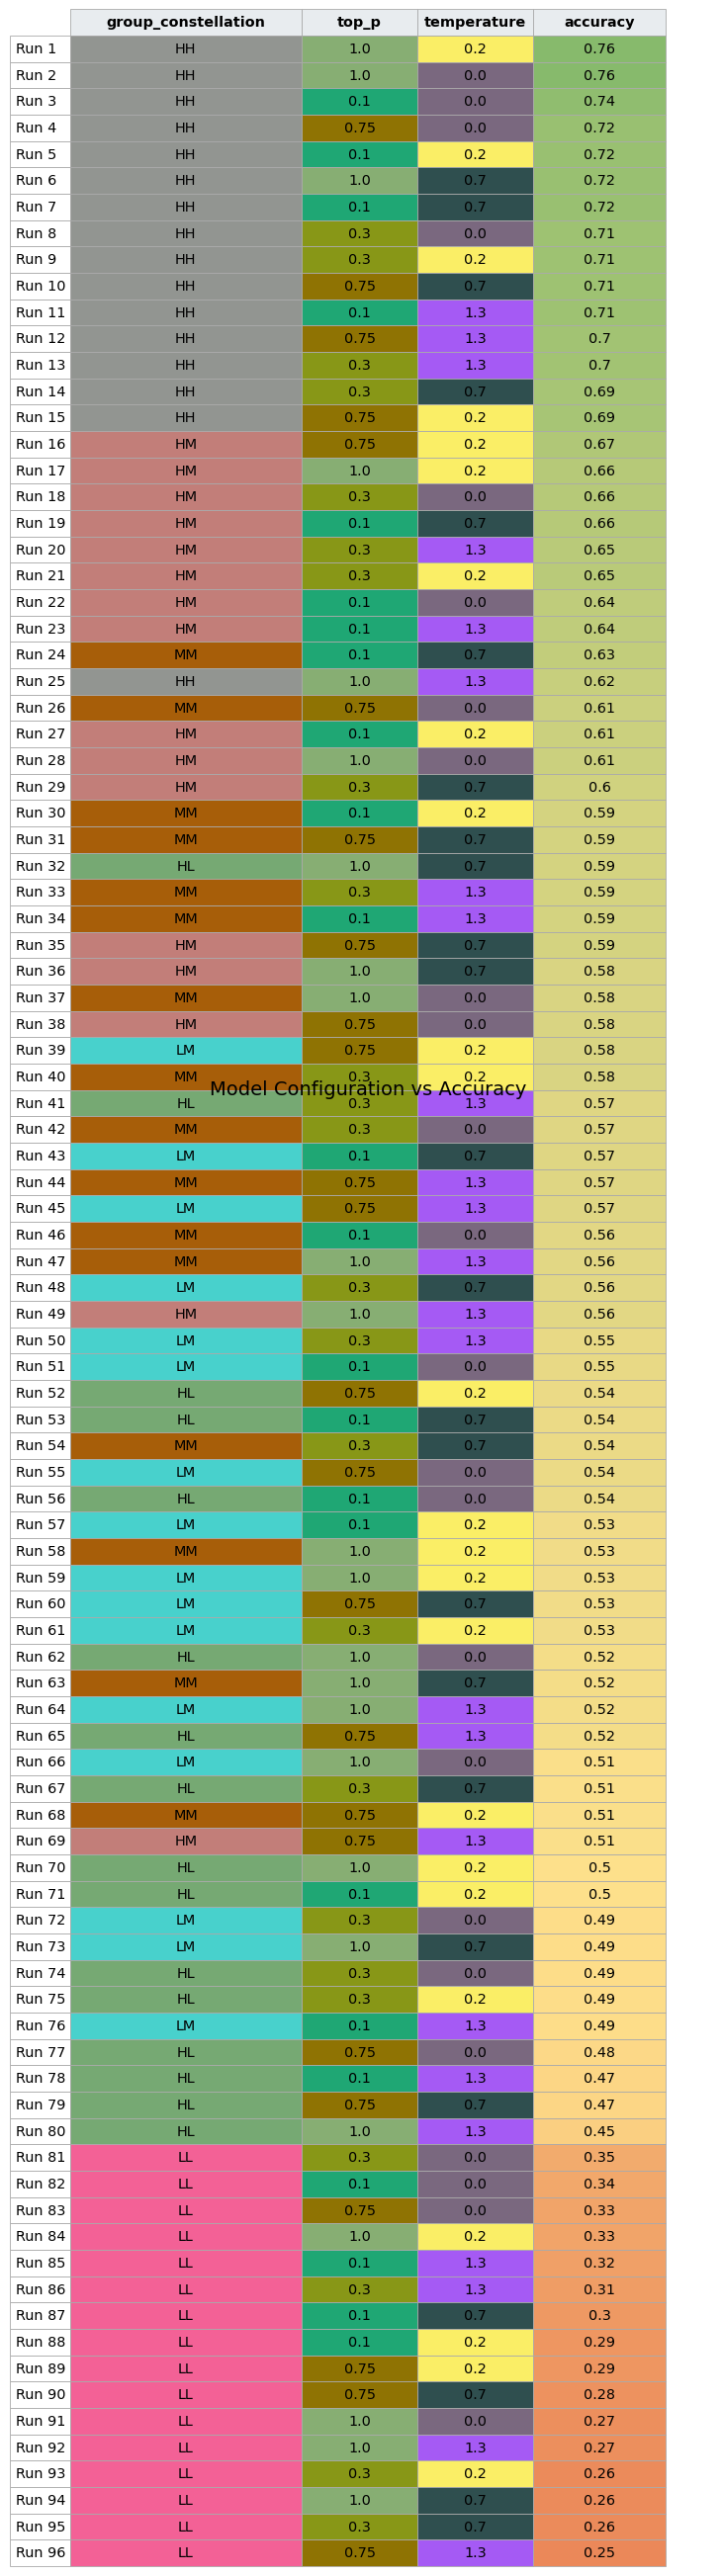

In [25]:
import random
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, get_named_colors_mapping

data = diversity_data.to_numpy()

col_labels = ["group_constellation", "top_p", "temperature", "accuracy"]
row_labels = [f"Run {i + 1}" for i in range(len(data))]

# ────────────────────────────────────────────────
# Color gradient: red → white → green for accuracy
# ────────────────────────────────────────────────

colors = ["#d73027", "#fee08b", "#1a9850"]  # red – light yellow – green
all_colors = list(get_named_colors_mapping().values())
cmap = LinearSegmentedColormap.from_list("acc", colors, N=256)


def acc_to_color(value):
    """Map accuracy [0,1] → color"""
    # Optional: clip just in case
    v = max(0.0, min(1.0, float(value)))
    return cmap(v)


# ────────────────────────────────────────────────
# Build 2D list of cell background colors
# ────────────────────────────────────────────────

category_colors = defaultdict(lambda: random.choice(all_colors))

cell_colors = []
for row in data:
    row_colors = []
    for j, val in enumerate(row):
        if j == 3:  # accuracy column (0-based index 3)
            color = acc_to_color(val)
        else:
            color = category_colors[val]
        row_colors.append(color)
    cell_colors.append(row_colors)

# ────────────────────────────────────────────────
# Create figure and table
# ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4.2))  # adjust as needed
ax.axis("off")

table = ax.table(
    cellText=data,
    cellColours=cell_colors,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colWidths=[0.28, 0.14, 0.14, 0.16],
)

table.auto_set_font_size(False)
table.set_fontsize(10.4)
table.scale(1.2, 1.6)  # horizontal / vertical stretch

# Optional: nicer grid
for (i, j), cell in table.get_celld().items():
    cell.set_edgecolor("#aaaaaa")
    cell.set_linewidth(0.6)
    # Make header row bold / different bg
    if i == 0:
        cell.set_facecolor("#e8ecef")
        cell.set_text_props(weight="bold")

# Optional title
plt.title("Model Configuration vs Accuracy", fontsize=14, pad=24)

plt.tight_layout()
plt.show()